# Two Roads to Diversity — Project Write-up Analysis

**Project:** *Unlocking Diversity in RL-Trained Reasoning Models*
**Authors:** Anna Grebenchtchikova & Chung Wong — Stanford CS224R, Spring 2026

**Thesis.** "Diversity" in RL-for-reasoning is **two knobs, not one.** Content-free **input noise** (random trivia prepended to training prompts, training-only) **sharpens** the policy (entropy goes down); the **negative gradient** in e3 **explores** (entropy goes up). Trivia buys efficiency at no in-distribution accuracy cost; combined with e3 it sits at the **sweet spot**. The boundary condition is long-horizon OOD transfer (MATH -> AIME), where the sharpening breaks.

---

**How to read this notebook.** It mirrors the 8-slide storyline in `CS224R_storyline_powerpointbuild.md`. Each slide gets a markdown cell with its action title and key points; slides that need empirical support get a code cell directly beneath that regenerates the chart/table from `results_version_G.json` and saves a deck-ready PNG to `figures/`.

## Setup — load data, track map, palette, helpers

The cell below loads `results_version_G.json`, defines the **Track <-> run-key** map and the deck color palette, and provides reusable helpers for extracting metric series, validation accuracy/length, cumulative tokens, AIME pass@1 with standard error, and saving PNGs to `figures/`.

In [2]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Paths ----
HERE = os.path.abspath(".")
DATA_PATH = os.path.join(HERE, "results_version_G.json")
FIG_DIR = os.path.join(HERE, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

with open(DATA_PATH) as f:
    DATA = json.load(f)

# ---- Track <-> run-key map (storyline section 4) ----
TRACKS = {
    "A": {"label": "GRPO clean",    "run": "gsm8k_clean",                 "color": "#051C2C", "ls": "-"},
    "B": {"label": "GRPO trivia",   "run": "gsm8k_trivia_only",           "color": "#FFA800", "ls": "-"},
    "C": {"label": "e3 clean",      "run": "gsm8k_partial_e3_clean",      "color": "#134F78", "ls": "-"},
    "D": {"label": "e3 trivia",     "run": "gsm8k_partial_e3_trivia",     "color": "#CD3030", "ls": "-"},
    "E": {"label": "e3 mixed (2M)", "run": "gsm8k_track_e_2M_partial_e3", "color": "#0679C3", "ls": "--"},
}
MATH_RUNS = {
    "MATH clean":  {"run": "math_clean",       "color": "#134F78", "ls": "-"},
    "MATH trivia": {"run": "math_trivia_only", "color": "#CD3030", "ls": "-"},
}

# batch 64 * rollout.n 8 = samples generated per step
SAMPLES_PER_STEP = 64 * 8

# ---- Plot style (deck DNA: white bg, Arial-metric, quiet chrome) ----
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans", "Arial", "DejaVu Sans"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


# ---- Helpers ----
def rows(run_key):
    return DATA["training"][run_key]["rows"]


def _val_keys(run_key, contains, must_end=None, exclude=()):
    allkeys = set().union(*[set(r.keys()) for r in rows(run_key)])
    out = []
    for k in allkeys:
        if not k.startswith("val/"):
            continue
        if contains not in k:
            continue
        if must_end and not k.endswith(must_end):
            continue
        if any(x in k for x in exclude):
            continue
        out.append(k)
    return sorted(out, key=len)


def series(run_key, metric=None, val_kind=None):
    """(steps, values) for a metric across logged rows.
    val_kind in {None, 'accuracy', 'length'} resolves dataset-specific val keys."""
    if val_kind == "accuracy":
        key = _val_keys(run_key, "test_score", exclude=("unknown",))[0]
    elif val_kind == "length":
        key = _val_keys(run_key, "length/mean", must_end="length/mean",
                        exclude=("0_length", "1_length", "unknown"))[0]
    else:
        key = metric
    steps, vals = [], []
    for r in rows(run_key):
        if key in r and r[key] is not None:
            steps.append(r.get("_step"))
            vals.append(r[key])
    return np.array(steps, dtype=float), np.array(vals, dtype=float)


def final_peak_accuracy(run_key):
    _, v = series(run_key, val_kind="accuracy")
    return (v[-1], v.max()) if len(v) else (np.nan, np.nan)


def cumulative_tokens_millions(run_key):
    """Per-step cumulative generated tokens (millions): cumsum(SAMPLES_PER_STEP * response_length)/1e6."""
    rs = [r for r in rows(run_key) if "response_length/mean" in r]
    steps = np.array([r["_step"] for r in rs], dtype=float)
    rl = np.array([r["response_length/mean"] for r in rs], dtype=float)
    cum = np.cumsum(rl * SAMPLES_PER_STEP) / 1e6
    return steps, cum


def tokens_at_step(run_key, target_steps):
    """Interpolate cumulative tokens (M) at the given training steps."""
    s, cum = cumulative_tokens_millions(run_key)
    return np.interp(target_steps, s, cum)


def rolling(y, window=7):
    if len(y) == 0:
        return y
    return pd.Series(y).rolling(window, center=True, min_periods=1).mean().to_numpy()


def aime_pass1(label):
    return DATA["aime"][label]["pass@1"]


def aime_se(label, n_problems=60):
    p = aime_pass1(label)
    return float(np.sqrt(p * (1 - p) / n_problems))


def savefig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path)
    print("saved ->", os.path.relpath(path, HERE))


print("Loaded:", os.path.relpath(DATA_PATH, HERE))
print("Training runs:", list(DATA["training"].keys()))
print("AIME labels:", list(DATA["aime"].keys()))

Loaded: results_version_G.json
Training runs: ['gsm8k_clean', 'gsm8k_trivia_only', 'gsm8k_partial_e3_clean', 'gsm8k_partial_e3_trivia', 'gsm8k_track_e_2M_partial_e3', 'math_clean', 'math_trivia_only']
AIME labels: ['Track A GSM8K', 'Track B GSM8K', 'Track C GSM8K (partial e3 clean)', 'Track D GSM8K (partial e3 trivia)', 'Track B MATH', 'Track A MATH', 'Track E GSM8K (2M mixed partial e3)']


# Slide 0 — Title

*Two Roads to Diversity: Input Noise Sharpens, Negative Gradients Explore.*

Anna Grebenchtchikova & Chung Wong · Stanford CS224R, Spring 2026.

**Artifact?** No — title slide only.

# Slide 1 — "Compute is the new gold — and 'diversity' is how RL spends it" (1/3 <-> 2/3)

**Left third:** the stakes — RL-for-reasoning explores, and exploration is expensive (pictogram: `$ / GPU -> tokens -> reasoning`).
**Right two-thirds:** the one-line thesis up front — diversity is two knobs, not one: input noise sharpens, the negative gradient explores.

**Artifact?** No — conceptual pictogram + thesis text. Compute-as-gold is the motivating north-star, **not** a result, so no chart from our data here.

# Slide 2 — "Today's recipe for 'diversity' gives inconsistent returns" (1/2 <-> 1/2)

**Left:** the RLAD inconsistency as a mini heat-strip / up-down arrows (helps base, hurts DAPO, varies by benchmark).
**Right:** the open question — how much is the *content* of a hint vs. merely *perturbing the input*?

**Artifact?** No JSON artifact. The data here is **RLAD Table 2** (Liu et al., 2025), which is *external* to `results_version_G.json`. The heat-strip is built from those published numbers, not our runs.

# Slide 3 — "A one-line trick matched accuracy at lower cost — so we stress-tested it" (2/3 <-> 1/3)

**Left two-thirds:** Chung's hook — clean vs. mixed GSM8K accuracy curves sitting on top of each other ("same accuracy").
**Right third:** the experiment grid (GRPO clean/trivia · e3 clean/trivia/mixed · MATH clean/trivia), with the *step-limited, mixture not more data* footnote.

**Artifact? YES.** (a) Overlapping accuracy curves for `gsm8k_clean` (A) vs `gsm8k_track_e_2M_partial_e3` (E). (b) Experiment-grid summary table with final/peak GSM8K accuracy per track.

saved -> figures/slide3_chung_clean_vs_mixed.png


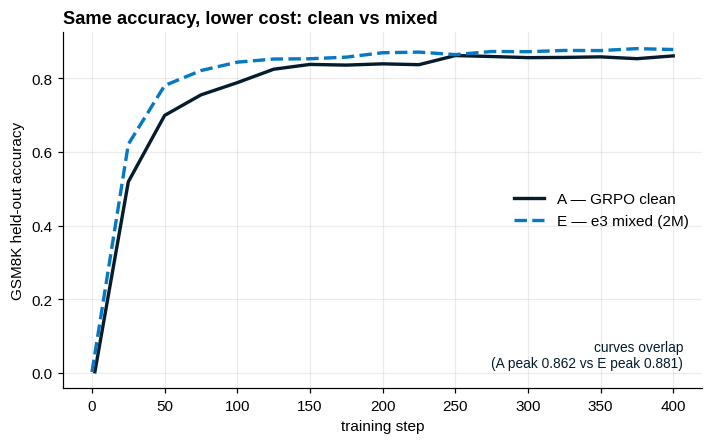

Step-limited: all runs 400 steps, batch 64, rollout.n 8 (25,600 samples).
'mixed (2M)' = 50/50 batch mixture, NOT more compute/data.


,Run,JSON key,Final acc,Peak acc
Track,,,,
A,GRPO clean,gsm8k_clean,0.861,0.862
B,GRPO trivia,gsm8k_trivia_only,0.846,0.871
C,e3 clean,gsm8k_partial_e3_clean,0.883,0.889
D,e3 trivia,gsm8k_partial_e3_trivia,0.883,0.883
E,e3 mixed (2M),gsm8k_track_e_2M_partial_e3,0.878,0.881


In [3]:
# (a) Chung hook: clean vs mixed GSM8K accuracy curves (overlapping)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for tk in ["A", "E"]:
    t = TRACKS[tk]
    s, acc = series(t["run"], val_kind="accuracy")
    ax.plot(s, acc, color=t["color"], ls=t["ls"], lw=2.2,
            label=f"{tk} — {t['label']}")
ax.set_xlabel("training step")
ax.set_ylabel("GSM8K held-out accuracy")
ax.set_title("Same accuracy, lower cost: clean vs mixed", loc="left", fontweight="bold")
ax.legend(frameon=False)
fa, pa = final_peak_accuracy(TRACKS["A"]["run"])
fe, pe = final_peak_accuracy(TRACKS["E"]["run"])
ax.annotate(f"curves overlap\n(A peak {pa:.3f} vs E peak {pe:.3f})",
            xy=(0.97, 0.05), xycoords="axes fraction", ha="right", va="bottom",
            fontsize=9, color="#051C2C")
savefig(fig, "slide3_chung_clean_vs_mixed.png")
plt.show()

# (b) Experiment-grid summary table
grid = []
for tk, t in TRACKS.items():
    f, p = final_peak_accuracy(t["run"])
    grid.append({"Track": tk, "Run": t["label"], "JSON key": t["run"],
                 "Final acc": round(f, 3), "Peak acc": round(p, 3)})
grid_df = pd.DataFrame(grid).set_index("Track")
print("Step-limited: all runs 400 steps, batch 64, rollout.n 8 (25,600 samples).")
print("'mixed (2M)' = 50/50 batch mixture, NOT more compute/data.")
grid_df

# Slide 4 — "Trivia keeps accuracy and reaches peak on roughly half the tokens" (3/4 <-> 1/4)

**Three-quarters:** the efficiency frontier (hero figure) — GSM8K accuracy vs cumulative tokens generated, all 5 GSM8K tracks, with each run ringed at 90%-of-its-peak.
**Right quarter:** takeaway stack — accuracy preserved · fewer truncations · ~21M vs ~40M tokens-to-peak.

**Artifact? YES.** (a) Efficiency-frontier plot (accuracy vs cumulative tokens, 90%-of-peak rings). (b) Tokens-to-90%-of-peak summary table.

saved -> figures/slide4_efficiency_frontier.png


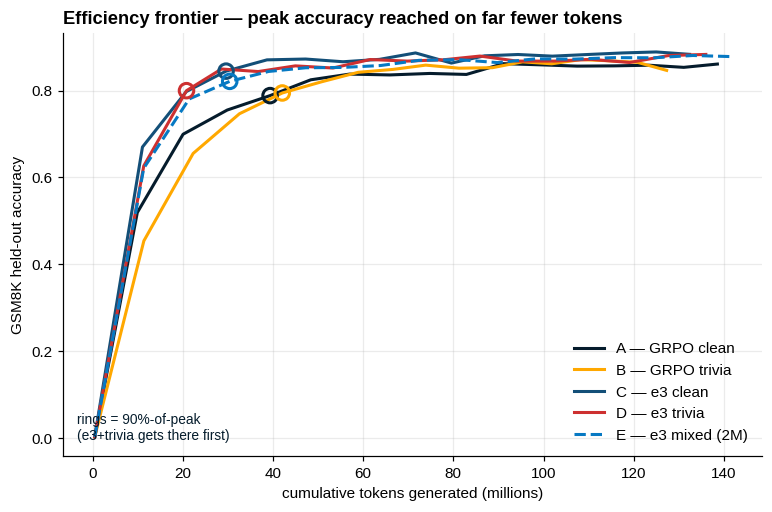

,Run,Tokens-to-90%-peak (M)
Track,,
D,e3 trivia,20.8
C,e3 clean,29.6
E,e3 mixed (2M),30.4
A,GRPO clean,39.3
B,GRPO trivia,42.1


In [4]:
# (a) Efficiency frontier: accuracy vs cumulative tokens generated (millions)
fig, ax = plt.subplots(figsize=(8.2, 5.0))
ttp = {}
for tk, t in TRACKS.items():
    s_acc, acc = series(t["run"], val_kind="accuracy")
    x = tokens_at_step(t["run"], s_acc)  # cumulative tokens (M) at each val step
    ax.plot(x, acc, color=t["color"], ls=t["ls"], lw=2.0, label=f"{tk} — {t['label']}")
    # ring the run at 90% of its own peak
    peak = acc.max()
    thr = 0.90 * peak
    idx = np.argmax(acc >= thr)
    ax.scatter([x[idx]], [acc[idx]], s=90, facecolors="none",
               edgecolors=t["color"], linewidths=2.0, zorder=5)
    ttp[tk] = x[idx]
ax.set_xlabel("cumulative tokens generated (millions)")
ax.set_ylabel("GSM8K held-out accuracy")
ax.set_title("Efficiency frontier — peak accuracy reached on far fewer tokens",
             loc="left", fontweight="bold")
ax.legend(frameon=False, loc="lower right")
ax.annotate("rings = 90%-of-peak\n(e3+trivia gets there first)",
            xy=(0.02, 0.04), xycoords="axes fraction", fontsize=9, color="#051C2C")
savefig(fig, "slide4_efficiency_frontier.png")
plt.show()

# (b) Tokens-to-90%-of-peak table
ttp_df = (pd.DataFrame([{"Track": k, "Run": TRACKS[k]["label"],
                         "Tokens-to-90%-peak (M)": round(v, 1)} for k, v in ttp.items()])
          .sort_values("Tokens-to-90%-peak (M)").set_index("Track"))
ttp_df

saved -> figures/slide4_ranked_efficiency_accuracy.png


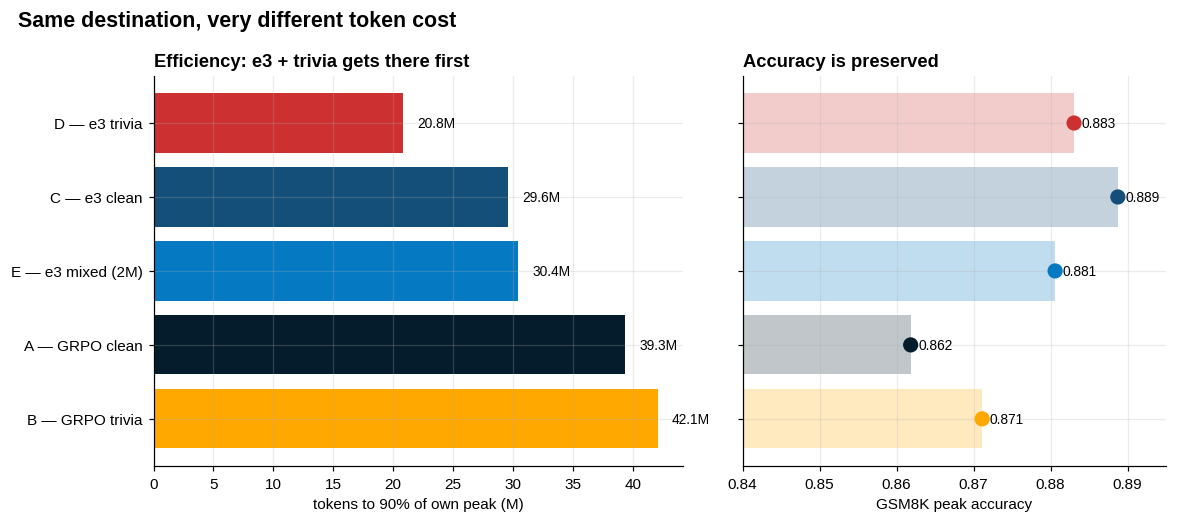

,Track,Run,Tokens-to-90%-peak (M),Peak accuracy,Final accuracy
0,D,e3 trivia,20.8,0.883,0.883
1,C,e3 clean,29.6,0.889,0.883
2,E,e3 mixed (2M),30.4,0.881,0.878
3,A,GRPO clean,39.3,0.862,0.861
4,B,GRPO trivia,42.1,0.871,0.846


In [8]:
def slide4_efficiency_summary(threshold=0.90):
    records = []
    for tk, t in TRACKS.items():
        s_acc, acc = series(t["run"], val_kind="accuracy")
        x = tokens_at_step(t["run"], s_acc)
        peak = float(acc.max())
        idx = int(np.argmax(acc >= threshold * peak))
        records.append({
            "Track": tk,
            "Run": t["label"],
            "Tokens-to-90%-peak (M)": float(x[idx]),
            "Peak accuracy": peak,
            "Final accuracy": float(acc[-1]),
            "color": t["color"],
        })
    return pd.DataFrame(records).sort_values("Tokens-to-90%-peak (M)").reset_index(drop=True)

slide4_eff = slide4_efficiency_summary()
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.8), gridspec_kw={"width_ratios": [1.25, 1]})
labels = [f"{r.Track} — {r.Run}" for r in slide4_eff.itertuples()]
colors = slide4_eff["color"].tolist()

ax = axes[0]
y = np.arange(len(slide4_eff))
ax.barh(y, slide4_eff["Tokens-to-90%-peak (M)"], color=colors)
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.set_xlabel("tokens to 90% of own peak (M)")
ax.set_title("Efficiency: e3 + trivia gets there first", loc="left", fontweight="bold")
for i, v in enumerate(slide4_eff["Tokens-to-90%-peak (M)"]):
    ax.text(v + 1.2, i, f"{v:.1f}M", va="center", fontsize=9)

ax = axes[1]
ax.barh(y, slide4_eff["Peak accuracy"], color=colors, alpha=0.25)
ax.scatter(slide4_eff["Peak accuracy"], y, color=colors, s=80, zorder=3)
ax.set_yticks(y, [])
ax.invert_yaxis()
ax.set_xlim(0.84, 0.895)
ax.set_xlabel("GSM8K peak accuracy")
ax.set_title("Accuracy is preserved", loc="left", fontweight="bold")
for i, v in enumerate(slide4_eff["Peak accuracy"]):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=9)

fig.suptitle("Same destination, very different token cost", x=0.02, ha="left", fontweight="bold", fontsize=14)
fig.tight_layout()
savefig(fig, "slide4_ranked_efficiency_accuracy.png")
plt.show()

display(slide4_eff.drop(columns="color").assign(**{
    "Tokens-to-90%-peak (M)": lambda d: d["Tokens-to-90%-peak (M)"].round(1),
    "Peak accuracy": lambda d: d["Peak accuracy"].round(3),
    "Final accuracy": lambda d: d["Final accuracy"].round(3),
}))

saved -> figures/slide4_token_savings_vs_grpo_clean.png


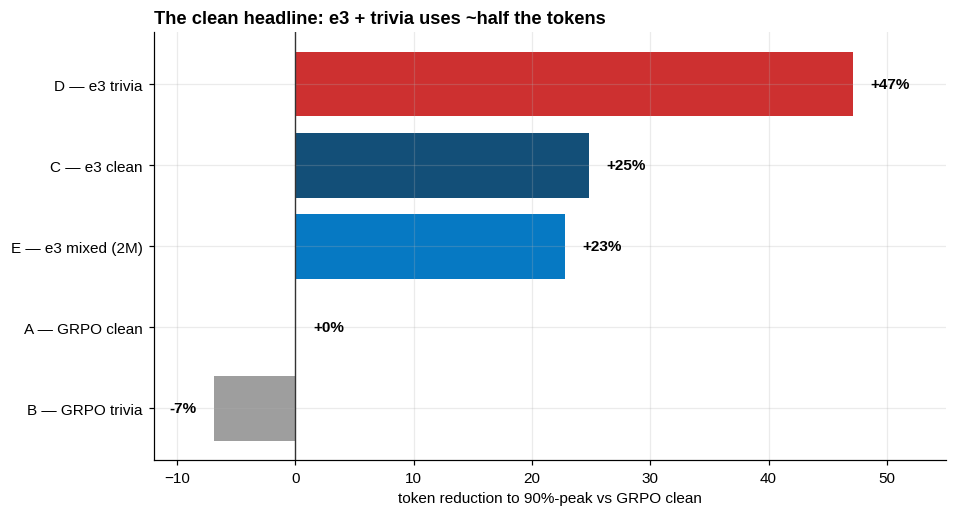

,Track,Run,Tokens-to-90%-peak (M),Token change vs GRPO clean (%),Peak accuracy
0,B,GRPO trivia,42.1,-6.9,0.871
1,A,GRPO clean,39.3,0.0,0.862
2,E,e3 mixed (2M),30.4,22.8,0.881
3,C,e3 clean,29.6,24.8,0.889
4,D,e3 trivia,20.8,47.1,0.883


In [9]:
base_tokens = float(slide4_eff.loc[slide4_eff["Track"] == "A", "Tokens-to-90%-peak (M)"].iloc[0])
savings = slide4_eff.copy()
savings["Token change vs GRPO clean (%)"] = 100 * (1 - savings["Tokens-to-90%-peak (M)"] / base_tokens)
savings = savings.sort_values("Token change vs GRPO clean (%)", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.8, 4.8))
y = np.arange(len(savings))
vals = savings["Token change vs GRPO clean (%)"]
colors = [r["color"] if v >= 0 else "#9E9E9E" for v, (_, r) in zip(vals, savings.iterrows())]
ax.barh(y, vals, color=colors)
ax.axvline(0, color="#333333", lw=0.9)
ax.set_yticks(y, [f"{r.Track} — {r.Run}" for r in savings.itertuples()])
ax.set_xlabel("token reduction to 90%-peak vs GRPO clean")
ax.set_title("The clean headline: e3 + trivia uses ~half the tokens", loc="left", fontweight="bold")
for i, v in enumerate(vals):
    xtext = v + (1.5 if v >= 0 else -1.5)
    ha = "left" if v >= 0 else "right"
    ax.text(xtext, i, f"{v:+.0f}%", va="center", ha=ha, fontsize=10, fontweight="bold")
ax.set_xlim(min(-12, vals.min() - 5), max(55, vals.max() + 6))
fig.tight_layout()
savefig(fig, "slide4_token_savings_vs_grpo_clean.png")
plt.show()

display(savings[["Track", "Run", "Tokens-to-90%-peak (M)", "Token change vs GRPO clean (%)", "Peak accuracy"]].assign(**{
    "Tokens-to-90%-peak (M)": lambda d: d["Tokens-to-90%-peak (M)"].round(1),
    "Token change vs GRPO clean (%)": lambda d: d["Token change vs GRPO clean (%)"].round(1),
    "Peak accuracy": lambda d: d["Peak accuracy"].round(3),
}))

saved -> figures/slide4_fixed_25m_budget.png


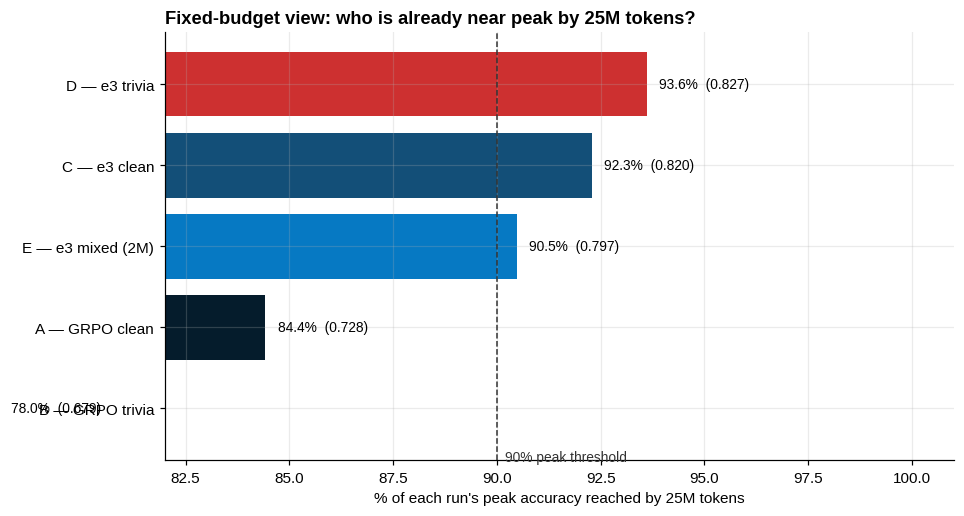

,Track,Run,Accuracy at budget,% of peak reached,Peak accuracy
0,D,e3 trivia,0.827,93.6,0.883
1,C,e3 clean,0.820,92.3,0.889
2,E,e3 mixed (2M),0.797,90.5,0.881
3,A,GRPO clean,0.728,84.4,0.862
4,B,GRPO trivia,0.679,78.0,0.871


In [10]:
budget_m = 25.0
budget_rows = []
for tk, t in TRACKS.items():
    s_acc, acc = series(t["run"], val_kind="accuracy")
    x = tokens_at_step(t["run"], s_acc)
    acc_at_budget = float(np.interp(budget_m, x, acc))
    peak = float(acc.max())
    budget_rows.append({
        "Track": tk,
        "Run": t["label"],
        "Accuracy at budget": acc_at_budget,
        "% of peak reached": 100 * acc_at_budget / peak,
        "Peak accuracy": peak,
        "color": t["color"],
    })

budget_df = pd.DataFrame(budget_rows).sort_values("% of peak reached", ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8.8, 4.8))
y = np.arange(len(budget_df))
ax.barh(y, budget_df["% of peak reached"], color=budget_df["color"].tolist())
ax.axvline(90, color="#333333", lw=1.0, ls="--")
ax.set_yticks(y, [f"{r.Track} — {r.Run}" for r in budget_df.itertuples()])
ax.invert_yaxis()
ax.set_xlim(82, 101)
ax.set_xlabel(f"% of each run's peak accuracy reached by {budget_m:.0f}M tokens")
ax.set_title("Fixed-budget view: who is already near peak by 25M tokens?", loc="left", fontweight="bold")
ax.text(90.2, len(budget_df) - 0.35, "90% peak threshold", fontsize=9, color="#333333")
for i, r in budget_df.iterrows():
    ax.text(r["% of peak reached"] + 0.3, i, f"{r['% of peak reached']:.1f}%  ({r['Accuracy at budget']:.3f})", va="center", fontsize=9)
fig.tight_layout()
savefig(fig, "slide4_fixed_25m_budget.png")
plt.show()

display(budget_df.drop(columns="color").assign(**{
    "Accuracy at budget": lambda d: d["Accuracy at budget"].round(3),
    "% of peak reached": lambda d: d["% of peak reached"].round(1),
    "Peak accuracy": lambda d: d["Peak accuracy"].round(3),
}))

# Slide 5 — "On MATH the model gets dramatically leaner for a 2-point price" (3/4 <-> 1/4)

**Three-quarters:** MATH response-length panel (~1325 clean vs ~727 trivia, ~45% leaner).
**Right quarter:** throughput-not-clock framing (same speed, fewer tokens -> finished in budget; clean was stitched) + forward hook to content-aware trivia.

*AIME addition:* ~45% leaner in-distribution for ~2pp accuracy, **but AIME transfer collapses 6x (0.146 -> 0.023)**.

**Artifact? YES.** (a) MATH validation response-length curves, clean vs trivia. (b) AIME MATH pass@1 bars (clean vs trivia) with SE error bars — the 6x collapse.

saved -> figures/slide5_math_length_and_aime.png


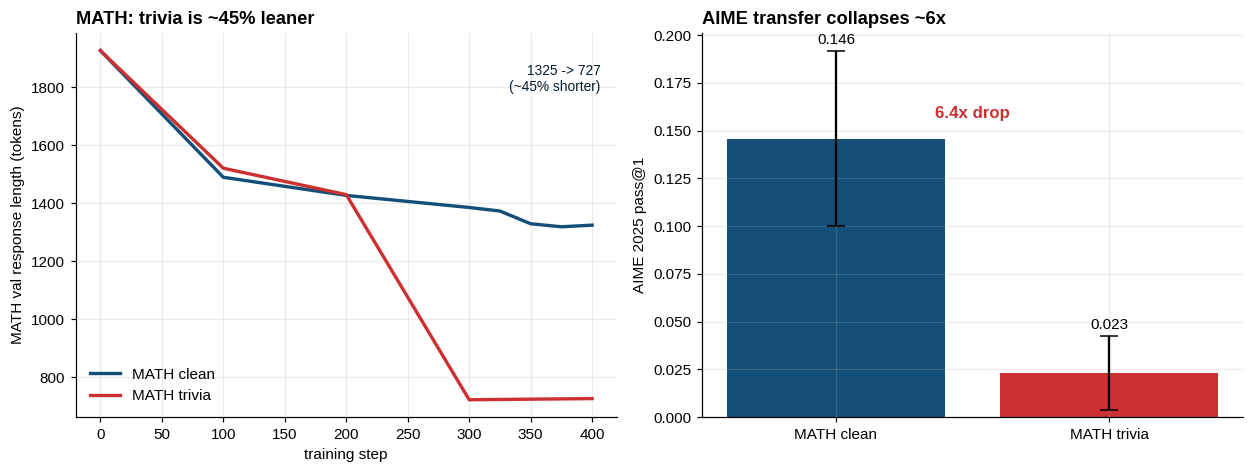

In [5]:
# (a) MATH response-length curves: clean vs trivia
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

ax = axes[0]
finals = {}
for name, m in MATH_RUNS.items():
    s, ln = series(m["run"], val_kind="length")
    ax.plot(s, ln, color=m["color"], ls=m["ls"], lw=2.2, label=name)
    if len(ln):
        finals[name] = ln[-1]
ax.set_xlabel("training step")
ax.set_ylabel("MATH val response length (tokens)")
ax.set_title("MATH: trivia is ~45% leaner", loc="left", fontweight="bold")
ax.legend(frameon=False)
if "MATH clean" in finals and "MATH trivia" in finals:
    pct = 100 * (1 - finals["MATH trivia"] / finals["MATH clean"])
    ax.annotate(f"{finals['MATH clean']:.0f} -> {finals['MATH trivia']:.0f}\n(~{pct:.0f}% shorter)",
                xy=(0.97, 0.92), xycoords="axes fraction", ha="right", va="top",
                fontsize=9, color="#051C2C")

# (b) AIME MATH bars with SE — the 6x collapse
ax = axes[1]
labels = ["Track A MATH", "Track B MATH"]
disp = ["MATH clean", "MATH trivia"]
colors = [MATH_RUNS["MATH clean"]["color"], MATH_RUNS["MATH trivia"]["color"]]
vals = [aime_pass1(l) for l in labels]
errs = [aime_se(l) for l in labels]
ax.bar(disp, vals, yerr=errs, capsize=6, color=colors)
ax.set_ylabel("AIME 2025 pass@1")
ax.set_title("AIME transfer collapses ~6x", loc="left", fontweight="bold")
for i, v in enumerate(vals):
    ax.text(i, v + errs[i] + 0.004, f"{v:.3f}", ha="center", fontsize=10)
ax.annotate(f"{vals[0]/vals[1]:.1f}x drop", xy=(0.5, 0.78), xycoords="axes fraction",
            ha="center", fontsize=11, color="#CD3030", fontweight="bold")

fig.tight_layout()
savefig(fig, "slide5_math_length_and_aime.png")
plt.show()

# Slide 6 — "The mechanism: trivia sharpens, e3 explores — opposite knobs" (1/2 <-> 1/2)

**Left:** KL-drift figure — all e3 runs stay far closer to base than either GRPO run; within e3, trivia & mixed are closest.
**Right:** the two-arrow conceptual diagram (input noise -> entropy down / sharpen; negative gradient -> entropy up / explore), plus the **twist**: low drift != guaranteed generalisation (MATH-trivia stays closest yet transfers worst).

*AIME addition:* GSM8K-trained AIME bars are **within error bars** — the only clear lever is the e3 gradient. Entropy lives here as **one sentence**, supported by the summary below.

**Artifact? YES.** (a) KL-drift curves (GSM8K + MATH, rolling-smoothed). (b) AIME GSM8K bars A-E with SE error bars. (c) One-line entropy summary table (sharpen vs explore).

saved -> figures/slide6_kl_drift.png


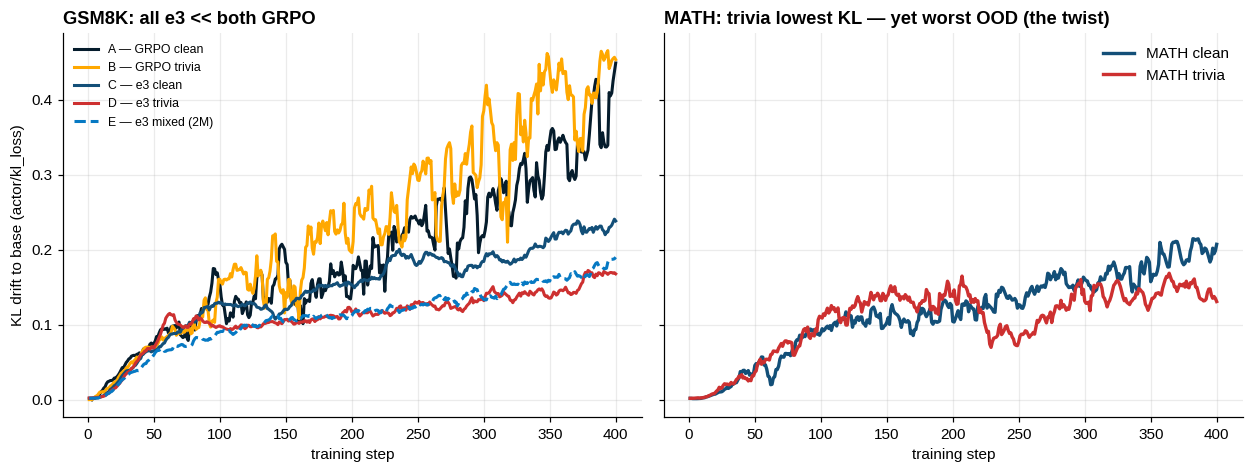

saved -> figures/slide6_aime_gsm8k_bars.png


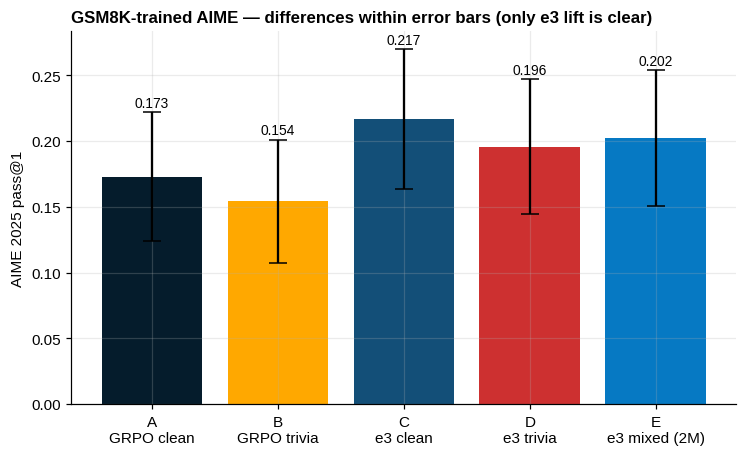

One sentence: GRPO/trivia collapse (low entropy = sharpen); e3 stays high (explore).


,Run,Final entropy
Track,,
A,GRPO clean,0.0187
B,GRPO trivia,0.0246
C,e3 clean,0.1761
D,e3 trivia,0.1314
E,e3 mixed (2M),0.1575


In [6]:
# (a) KL drift to base (actor/kl_loss), rolling-smoothed
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)

ax = axes[0]
for tk, t in TRACKS.items():
    s, kl = series(t["run"], metric="actor/kl_loss")
    ax.plot(s, rolling(kl), color=t["color"], ls=t["ls"], lw=2.0, label=f"{tk} — {t['label']}")
ax.set_xlabel("training step"); ax.set_ylabel("KL drift to base (actor/kl_loss)")
ax.set_title("GSM8K: all e3 << both GRPO", loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
for name, m in MATH_RUNS.items():
    s, kl = series(m["run"], metric="actor/kl_loss")
    ax.plot(s, rolling(kl), color=m["color"], ls=m["ls"], lw=2.2, label=name)
ax.set_xlabel("training step")
ax.set_title("MATH: trivia lowest KL — yet worst OOD (the twist)", loc="left", fontweight="bold")
ax.legend(frameon=False)
fig.tight_layout()
savefig(fig, "slide6_kl_drift.png")
plt.show()

# (b) AIME GSM8K bars A-E with SE (within error bars)
fig, ax = plt.subplots(figsize=(7.8, 4.4))
aime_gsm = {
    "A": "Track A GSM8K", "B": "Track B GSM8K",
    "C": "Track C GSM8K (partial e3 clean)", "D": "Track D GSM8K (partial e3 trivia)",
    "E": "Track E GSM8K (2M mixed partial e3)",
}
xs = list(aime_gsm.keys())
vals = [aime_pass1(aime_gsm[k]) for k in xs]
errs = [aime_se(aime_gsm[k]) for k in xs]
cols = [TRACKS[k]["color"] for k in xs]
ax.bar([f"{k}\n{TRACKS[k]['label']}" for k in xs], vals, yerr=errs, capsize=6, color=cols)
ax.set_ylabel("AIME 2025 pass@1")
ax.set_title("GSM8K-trained AIME — differences within error bars (only e3 lift is clear)",
             loc="left", fontweight="bold", fontsize=11)
for i, v in enumerate(vals):
    ax.text(i, v + errs[i] + 0.004, f"{v:.3f}", ha="center", fontsize=9)
savefig(fig, "slide6_aime_gsm8k_bars.png")
plt.show()

# (c) One-line entropy summary: trivia sharpens (entropy down), e3 explores (entropy up)
ent = []
for tk, t in TRACKS.items():
    _, e = series(t["run"], metric="actor/entropy")
    ent.append({"Track": tk, "Run": t["label"], "Final entropy": round(float(e[-1]), 4)})
ent_df = pd.DataFrame(ent).set_index("Track")
print("One sentence: GRPO/trivia collapse (low entropy = sharpen); e3 stays high (explore).")
ent_df

# Slide 7 — "Together they're the sweet spot — and here's where it goes next" (2/3 <-> 1/3)

**Left two-thirds:** the synthesis — e3 + trivia = most token-efficient AND closest to base (converging-arrows / 2x2 visual).
**Right third:** future work timeline (domain trivia on MATH -> more AIME conditions -> scale to o4-mini, tying to RLAD's weak-to-strong).

**Artifact? YES (synthesis).** A 2x2 scatter placing each GSM8K track by tokens-to-peak (efficiency, x) vs final KL drift (closeness-to-base, y) — the e3+trivia point should sit in the bottom-left winning quadrant.

saved -> figures/slide7_sweet_spot.png


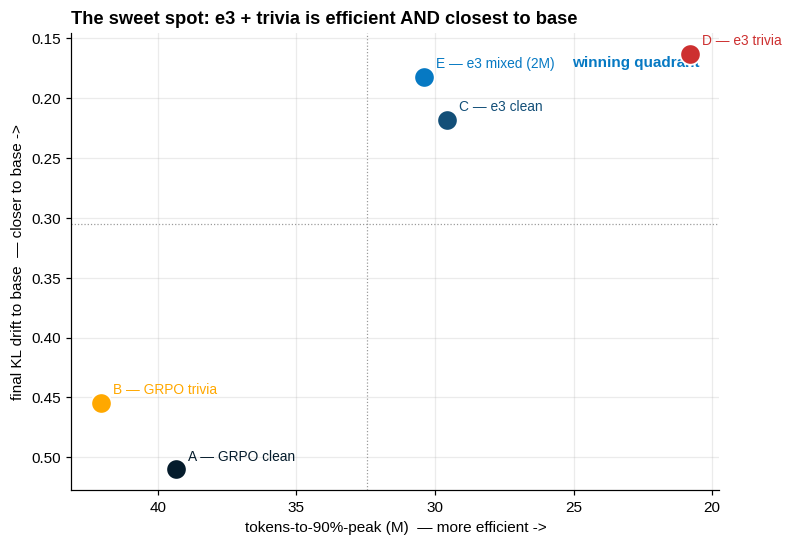

In [7]:
# Sweet-spot 2x2: tokens-to-90%-peak (x) vs final KL drift (y); bottom-left = winning quadrant
fig, ax = plt.subplots(figsize=(7.6, 5.4))
pts = {}
for tk, t in TRACKS.items():
    s_acc, acc = series(t["run"], val_kind="accuracy")
    x = tokens_at_step(t["run"], s_acc)
    peak = acc.max(); idx = np.argmax(acc >= 0.90 * peak)
    tokens_to_peak = x[idx]
    _, kl = series(t["run"], metric="actor/kl_loss")
    pts[tk] = (tokens_to_peak, float(kl[-1]))
    ax.scatter(*pts[tk], s=180, color=t["color"], zorder=5,
               edgecolors="white", linewidths=1.2)
    ax.annotate(f"{tk} — {t['label']}", pts[tk],
                textcoords="offset points", xytext=(8, 6), fontsize=9, color=t["color"])

xmid = np.mean([v[0] for v in pts.values()])
ymid = np.mean([v[1] for v in pts.values()])
ax.axvline(xmid, color="#999999", lw=0.8, ls=":")
ax.axhline(ymid, color="#999999", lw=0.8, ls=":")
ax.set_xlabel("tokens-to-90%-peak (M)  — more efficient ->")
ax.set_ylabel("final KL drift to base  — closer to base ->")
ax.invert_xaxis(); ax.invert_yaxis()  # winning (efficient + close) lands top-right after inversion
ax.set_title("The sweet spot: e3 + trivia is efficient AND closest to base",
             loc="left", fontweight="bold")
ax.annotate("winning quadrant", xy=(0.97, 0.95), xycoords="axes fraction",
            ha="right", va="top", fontsize=10, color="#0679C3", fontweight="bold")
savefig(fig, "slide7_sweet_spot.png")
plt.show()